# GNN Depth vs. Robust Expressivity: Oversmoothing Study

Supports **GIN** and **GCN** — set `ARCH` in the Setup cell.

- **GIN** (Xu et al. 2019): injective sum aggregation, maximally expressive.
- **GCN** (Kipf & Welling 2017): normalised mean aggregation, prone to oversmoothing.

**Core question:** Does increasing depth $L$ collapse the model-based margin $\hat{\gamma}_{f(A)}$ through oversmoothing, and does this directly predict alignment failure under edge perturbations?

$$\hat{\gamma}_{f(A)} = \min_{i \neq j} \|[f(A)]_i - [f(A)]_j\|_2$$

Robust node-level expressivity (Proposition 1): the GNN survives perturbation $k$ if $\|f(A) - f(A')\|_2 < \hat{\gamma}_{f(A)}$.

In [1]:
%%capture
!pip install torch_geometric

## 0. Setup

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv, GCNConv
from torch_geometric.data import Data

import numpy as np
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import random, warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# ── Architecture choice ───────────────────────────────────────────────────────
ARCH = 'GCN'   # 'GIN' or 'GCN'

# ── Hyperparameters ──────────────────────────────────────────────────────────
N_NODES      = 30
ER_PROB      = 0.4
FEAT_DIM     = 1
HIDDEN_DIM   = 64
EMBED_DIM    = 32
TRAIN_STEPS  = 1000
LR           = 5e-4
N_TEST       = 80
K_VALUES     = [0, 1, 2, 3, 4, 5, 6, 8]
FIXED_MARGIN = 0.5
DEPTH_VALUES = [3,4,5,6]

plt.rcParams.update({'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'figure.dpi': 130})
CMAP_L = cm.viridis

Using device: cuda


## 1. Graph Generation and Perturbation

In [30]:
def sample_er_graph(n=N_NODES, p=ER_PROB, feat_dim=FEAT_DIM, seed=None):
    rng = np.random.RandomState(seed) if seed is not None else np.random
    A = np.zeros((n, n), dtype=np.float32)
    for i in range(n):
        for j in range(i + 1, n):
            if rng.rand() < p:
                A[i, j] = A[j, i] = 1.0
    rand_attrs = (rng.randn(n, feat_dim - 1) * 0.1).astype(np.float32)
    degree     = (A.sum(axis=1, keepdims=True) / n).astype(np.float32)
    feats      = np.concatenate([degree, rand_attrs], axis=1)
    return A, feats


def perturb_graph(A, feats, k, seed=None):
    rng        = np.random.RandomState(seed) if seed is not None else np.random
    n          = A.shape[0]
    Ap         = A.copy()
    rows, cols = np.triu_indices(n, k=1)
    chosen     = rng.choice(len(rows), min(k, len(rows)), replace=False)
    for idx in chosen:
        r, c = rows[idx], cols[idx]
        Ap[r, c] = Ap[c, r] = 1.0 - Ap[r, c]
    featsp       = feats.copy()
    featsp[:, 0] = Ap.sum(axis=1) / n
    return Ap, featsp


def to_pyg(A, feats, device=DEVICE):
    edge_index = torch.tensor(np.array(np.where(A > 0)), dtype=torch.long)
    x          = torch.tensor(feats, dtype=torch.float32)
    return Data(x=x, edge_index=edge_index, num_nodes=A.shape[0]).to(device)


A, feats   = sample_er_graph(seed=0)
Ap, featsp = perturb_graph(A, feats, k=2, seed=0)
print(f'Graph: {N_NODES} nodes, {int(A.sum()/2)} edges')
print(f'Edit distance after k=2 flip: {int(np.abs(A-Ap).sum()/2)}')

Graph: 30 nodes, 180 edges
Edit distance after k=2 flip: 2


## 2. GNN Architectures

**GIN** uses injective sum aggregation — maximally expressive per the WL hierarchy.  
**GCN** uses symmetric normalised mean — smooth but prone to oversmoothing at depth.  
Both L2-normalise embeddings onto the unit hypersphere so distances lie in $[0, 2]$.

In [31]:
class GINEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, num_layers):
        super().__init__()
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()
        dims = [in_dim] + [hidden_dim] * (num_layers - 1) + [out_dim]
        for i in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(dims[i], dims[i+1]), nn.ReLU(),
                nn.Linear(dims[i+1], dims[i+1]),
            )
            self.convs.append(GINConv(mlp, train_eps=True))
            self.bns.append(nn.BatchNorm1d(dims[i+1]))

    def forward(self, data):
        x, ei = data.x, data.edge_index
        for conv, bn in zip(self.convs, self.bns):
            x = F.relu(bn(conv(x, ei)))
        return F.normalize(x, p=2, dim=1)


class GCNEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, num_layers):
        super().__init__()
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()
        dims = [in_dim] + [hidden_dim] * (num_layers - 1) + [out_dim]
        for i in range(num_layers):
            self.convs.append(GCNConv(dims[i], dims[i+1]))
            self.bns.append(nn.BatchNorm1d(dims[i+1]))

    def forward(self, data):
        x, ei = data.x, data.edge_index
        for conv, bn in zip(self.convs, self.bns):
            x = F.relu(bn(conv(x, ei)))
        return F.normalize(x, p=2, dim=1)


ARCH_REGISTRY = {'GIN': GINEncoder, 'GCN': GCNEncoder}


def compute_margin(emb):
    with torch.no_grad():
        d    = torch.cdist(emb, emb, p=2)
        mask = ~torch.eye(d.shape[0], dtype=torch.bool, device=d.device)
        return d[mask].min().item()


def hungarian_alignment_accuracy(emb_A, emb_Ap):
    with torch.no_grad():
        C = torch.cdist(emb_A, emb_Ap, p=2).cpu().numpy()
        if C.max() - C.min() < 1e-8:
            n = C.shape[0]
            return np.mean(np.arange(n) == np.random.permutation(n))
        row_ind, col_ind = linear_sum_assignment(C)
        return np.sum(row_ind == col_ind) / len(row_ind)


for name, Cls in ARCH_REGISTRY.items():
    m   = Cls(FEAT_DIM, HIDDEN_DIM, EMBED_DIM, 3).to(DEVICE)
    out = m(to_pyg(A, feats))
    print(f'{name}: shape={list(out.shape)}  norm={out.norm(dim=1).mean():.4f}  '
          f'margin={compute_margin(out):.4f}')

GIN: shape=[30, 32]  norm=1.0000  margin=0.2602
GCN: shape=[30, 32]  norm=1.0000  margin=0.2466


## 3. Triplet Margin Loss

$$\mathcal{L}(m) = \frac{1}{n} \sum_{i=1}^n \max\bigl(0,\; d_{\text{pos}} - d_{\text{neg}} + m\bigr)$$

In [32]:
def triplet_margin_loss(emb_A, emb_Ap, margin):
    n       = emb_A.shape[0]
    d_pos   = (emb_A - emb_Ap).norm(p=2, dim=1)
    shift   = torch.randint(1, n, (n,), device=emb_A.device)
    neg_idx = (torch.arange(n, device=emb_A.device) + shift) % n
    d_neg   = (emb_A - emb_A[neg_idx]).norm(p=2, dim=1)
    return F.relu(d_pos - d_neg + margin).mean()


print('Triplet loss defined.')

Triplet loss defined.


## 4. Training — Depth Sweep

Triplet margin $m = 0.5$ fixed. One model per depth $L \in$ `DEPTH_VALUES`.  
Architecture is controlled by `ARCH` set in the Setup cell.

In [33]:
def train_model(num_layers, arch=ARCH, margin=FIXED_MARGIN,
                steps=TRAIN_STEPS, seed=42):
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    Cls   = ARCH_REGISTRY[arch]
    model = Cls(FEAT_DIM, HIDDEN_DIM, EMBED_DIM, num_layers).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=LR)
    for _ in range(steps):
        model.train()
        A, feats   = sample_er_graph()
        Ap, featsp = perturb_graph(A, feats, k=0)
        emb_A      = model(to_pyg(A, feats))
        emb_Ap     = model(to_pyg(Ap, featsp))
        loss       = triplet_margin_loss(emb_A, emb_Ap, margin)
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
    return model


print(f'Training {ARCH} depth sweep (m={FIXED_MARGIN} fixed)...')
depth_models = {}
for L in DEPTH_VALUES:
    print(f'  L={L} ...', end=' ', flush=True)
    depth_models[L] = train_model(num_layers=L)
    print('done')
print('All models trained.')

Training GCN depth sweep (m=0.5 fixed)...
  L=3 ... done
  L=4 ... done
  L=5 ... done
  L=6 ... done
All models trained.


## 5. Evaluation

In [34]:
def evaluate_model(model, k_values=K_VALUES, n_test=N_TEST):
    model.eval()
    gamma_list = []
    acc   = {k: [] for k in k_values}
    shift = {k: [] for k in k_values}
    with torch.no_grad():
        for seed in range(n_test):
            A, feats = sample_er_graph(seed=seed + 2000)
            emb_A    = model(to_pyg(A, feats))
            gamma_list.append(compute_margin(emb_A))
            for k in k_values:
                if k == 0:
                    acc[0].append(1.0); shift[0].append(0.0)
                else:
                    Ap, featsp = perturb_graph(A, feats, k, seed=seed)
                    emb_Ap     = model(to_pyg(Ap, featsp))
                    acc[k].append(hungarian_alignment_accuracy(emb_A, emb_Ap))
                    shift[k].append(
                        (emb_A - emb_Ap).norm(p=2, dim=1).mean().item()
                    )
    return {
        'gamma_mean': np.mean(gamma_list), 'gamma_std': np.std(gamma_list),
        'gamma_all':  gamma_list,
        'acc':        {k: np.mean(v) for k, v in acc.items()},
        'shift':      {k: np.mean(v) for k, v in shift.items()},
        'acc_all': acc, 'shift_all': shift,
    }


print(f'Evaluating {ARCH} depth sweep...')
depth_results = {}
for L, model in depth_models.items():
    depth_results[L] = evaluate_model(model)
    r = depth_results[L]
    print(f'  L={L}: gamma={r["gamma_mean"]:.4f}+/-{r["gamma_std"]:.4f}  '
          f'acc@k=1={r["acc"][1]:.3f}  acc@k=5={r["acc"][5]:.3f}')

Evaluating GCN depth sweep...
  L=3: gamma=0.0321+/-0.0250  acc@k=1=0.985  acc@k=5=0.604
  L=4: gamma=0.0279+/-0.0324  acc@k=1=0.889  acc@k=5=0.527
  L=5: gamma=0.0086+/-0.0102  acc@k=1=0.706  acc@k=5=0.426
  L=6: gamma=0.0031+/-0.0043  acc@k=1=0.621  acc@k=5=0.363


## 6. Figures

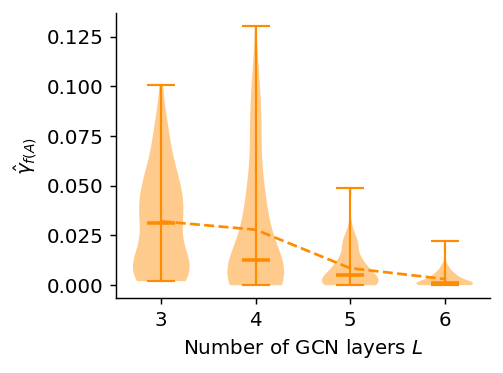

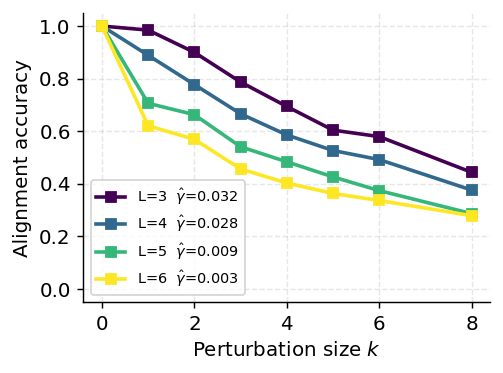

In [39]:
Ls       = DEPTH_VALUES
gammas_d = [depth_results[L]['gamma_mean'] for L in Ls]
g_stds_d = [depth_results[L]['gamma_std']  for L in Ls]
normL    = plt.Normalize(vmin=min(Ls), vmax=max(Ls))

# --- Figure A: margin vs depth (violin) ---
fig1, ax = plt.subplots(figsize=(4, 3))
gamma_data = [depth_results[L]['gamma_all'] for L in Ls]
parts = ax.violinplot(gamma_data, positions=Ls, widths=0.6, showmedians=True)
parts['cmedians'].set_color('darkorange'); parts['cmedians'].set_linewidth(2)
for pc in parts['bodies']:
    pc.set_facecolor('darkorange'); pc.set_alpha(0.45)
for key in ('cbars', 'cmins', 'cmaxes'):
    parts[key].set_color('darkorange'); parts[key].set_linewidth(1.2)
ax.plot(Ls, gammas_d, color='darkorange', linestyle='--')
ax.set_xlabel(f'Number of {ARCH} layers $L$')
ax.set_ylabel('$\\hat{\\gamma}_{f(A)}$')
# ax.set_title(f'{ARCH}: Margin distribution vs. depth')
ax.set_xticks(Ls)
fig1.tight_layout()
fig1.savefig(f'ER_{ARCH.lower()}_depth_margin.pdf', bbox_inches='tight')
fig1.savefig(f'ER_{ARCH.lower()}_depth_margin.png', bbox_inches='tight', dpi=150)
plt.show()

# --- Figure B: accuracy vs perturbation ---
fig2, ax = plt.subplots(figsize=(4, 3))
for L in Ls:
    r  = depth_results[L]
    ks = sorted(r['acc'].keys())
    ax.plot(ks, [r['acc'][k] for k in ks], 's-', color=CMAP_L(normL(L)),
            linewidth=2, markersize=5,
            label=f'L={L}  $\\hat{{\\gamma}}$={r["gamma_mean"]:.3f}')
ax.set_xlabel('Perturbation size $k$')
ax.set_ylabel('Alignment accuracy')
ax.legend(fontsize=8, loc='lower left')
ax.set_ylim(-0.05, 1.05)
ax.grid(True, linestyle='--', alpha=0.3)
fig2.tight_layout()
fig2.savefig(f'ER_{ARCH.lower()}_depth_acc_vs_k.pdf', bbox_inches='tight')
fig2.savefig(f'ER_{ARCH.lower()}_depth_acc_vs_k.png', bbox_inches='tight', dpi=150)
plt.show()

### Embedding Shift vs. Depth

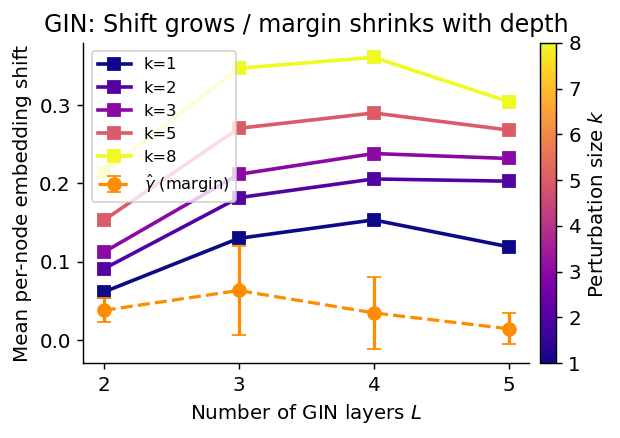

In [9]:
k_plot  = [1, 2, 3, 5, 8]
norm_k  = plt.Normalize(vmin=min(k_plot), vmax=max(k_plot))
cmap_k  = cm.plasma

fig3, ax = plt.subplots(figsize=(5, 3.5))
for k in k_plot:
    shifts = [depth_results[L]['shift'][k] for L in Ls]
    ax.plot(Ls, shifts, 's-', color=cmap_k(norm_k(k)),
            linewidth=2, markersize=7, label=f'k={k}')
ax.errorbar(Ls, gammas_d, yerr=g_stds_d, fmt='o--', color='darkorange',
            capsize=4, linewidth=1.8, markersize=7,
            label=r'$\hat{\gamma}$ (margin)')
ax.set_xlabel(f'Number of {ARCH} layers $L$')
ax.set_ylabel('Mean per-node embedding shift')
ax.set_title(f'{ARCH}: Shift grows / margin shrinks with depth')
ax.set_xticks(Ls)
ax.legend(fontsize=9, loc='upper left')
plt.colorbar(cm.ScalarMappable(cmap=cmap_k, norm=norm_k), ax=ax,
             label='Perturbation size $k$', pad=0.02)
fig3.tight_layout()
fig3.savefig(f'{ARCH.lower()}_depth_shift.pdf', bbox_inches='tight')
fig3.savefig(f'{ARCH.lower()}_depth_shift.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. Summary Table

In [10]:
def empirical_threshold(acc_by_k, cutoff=0.9):
    for k in sorted(acc_by_k.keys(), reverse=True):
        if acc_by_k[k] >= cutoff:
            return k
    return 0


hdr = f"{'Config':<12} {'gamma_mean':>10} {'gamma_std':>9} {'acc@k=1':>9} {'acc@k=3':>9} {'acc@k=5':>9} {'k*':>4}"
print(hdr); print('\u2500' * len(hdr))

for L in DEPTH_VALUES:
    r = depth_results[L]
    print(f"{ARCH}/L={L}    {r['gamma_mean']:>10.4f} {r['gamma_std']:>9.4f} "
          f"{r['acc'].get(1, float('nan')):>9.3f} {r['acc'].get(3, float('nan')):>9.3f} "
          f"{r['acc'].get(5, float('nan')):>9.3f} {empirical_threshold(r['acc']):>4}")

Config       gamma_mean gamma_std   acc@k=1   acc@k=3   acc@k=5   k*
────────────────────────────────────────────────────────────────────
GIN/L=2        0.0378    0.0155     0.989     0.838     0.654    2
GIN/L=3        0.0632    0.0574     0.988     0.784     0.593    1
GIN/L=4        0.0346    0.0456     0.851     0.595     0.436    0
GIN/L=5        0.0143    0.0201     0.808     0.617     0.449    0


## 8. Theory Check: Relative Shift Predicts Accuracy

Proposition 1 gives a sufficient condition: robustness holds when per-node shift $< \hat{\gamma}$.

$$\text{relative shift} = \frac{\|[f(A)]_i - [f(A')]_i\|_2}{\hat{\gamma}_{f(A)}}$$

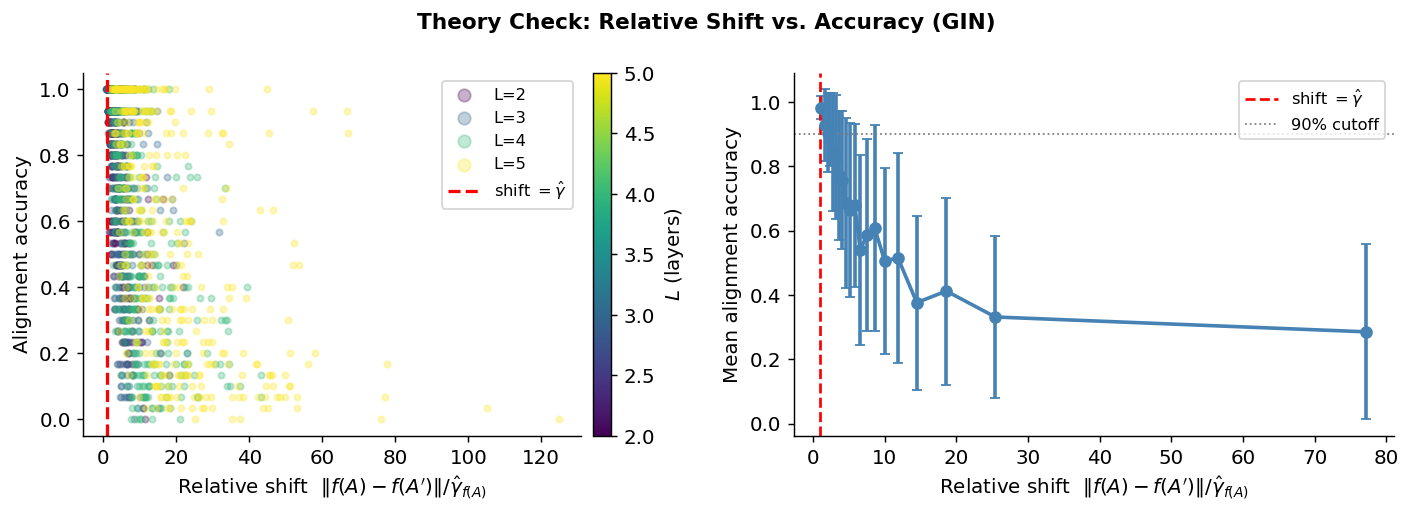

Theory check complete. Total data points: 1580


In [11]:
def collect_relative_shift_records(model, k_values=[1, 2, 3, 5, 8],
                                   n_test=N_TEST, depth=None):
    model.eval()
    records = []
    with torch.no_grad():
        for seed in range(n_test):
            A, feats = sample_er_graph(seed=seed + 2000)
            emb_A    = model(to_pyg(A, feats))
            gamma    = compute_margin(emb_A)
            if gamma < 1e-6:
                continue
            for k in k_values:
                Ap, featsp = perturb_graph(A, feats, k, seed=seed)
                emb_Ap     = model(to_pyg(Ap, featsp))
                mean_shift = (emb_A - emb_Ap).norm(p=2, dim=1).mean().item()
                acc        = hungarian_alignment_accuracy(emb_A, emb_Ap)
                records.append({'k': k, 'gamma': gamma,
                                'rel_shift': mean_shift / gamma,
                                'acc': acc, 'depth': depth})
    return records


all_records = []
for L, model in depth_models.items():
    all_records.extend(collect_relative_shift_records(model, depth=L))

rel_shifts  = np.array([r['rel_shift'] for r in all_records])
accs_arr    = np.array([r['acc']       for r in all_records])
depths_arr  = np.array([r['depth']     for r in all_records])

bins = np.unique(np.percentile(rel_shifts, np.linspace(0, 100, 21)))
bin_mid, bin_acc, bin_std = [], [], []
for lo, hi in zip(bins[:-1], bins[1:]):
    mask = (rel_shifts >= lo) & (rel_shifts < hi)
    if mask.sum() > 3:
        bin_mid.append((lo + hi) / 2)
        bin_acc.append(accs_arr[mask].mean())
        bin_std.append(accs_arr[mask].std())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle(f'Theory Check: Relative Shift vs. Accuracy ({ARCH})',
             fontsize=12, fontweight='bold')

ax = axes[0]
for L in DEPTH_VALUES:
    mask = depths_arr == L
    ax.scatter(rel_shifts[mask], accs_arr[mask], alpha=0.3, s=12,
               color=CMAP_L(normL(L)), label=f'L={L}')
ax.axvline(1.0, color='red', linestyle='--', linewidth=1.8,
           label='shift $= \\hat{\\gamma}$')
ax.set_xlabel('Relative shift  $\\|f(A)-f(A^\\prime)\\| / \\hat{\\gamma}_{f(A)}$')
ax.set_ylabel('Alignment accuracy')
ax.legend(fontsize=9, markerscale=2)
plt.colorbar(cm.ScalarMappable(cmap=CMAP_L, norm=normL), ax=ax,
             label='$L$ (layers)', pad=0.02)

ax = axes[1]
ax.errorbar(bin_mid, bin_acc, yerr=bin_std, fmt='o-', color='steelblue',
            capsize=3, linewidth=2, markersize=6)
ax.axvline(1.0, color='red', linestyle='--', linewidth=1.5,
           label='shift $= \\hat{\\gamma}$')
ax.axhline(0.9, color='grey', linestyle=':', linewidth=1.0, label='90% cutoff')
ax.set_xlabel('Relative shift  $\\|f(A)-f(A^\\prime)\\| / \\hat{\\gamma}_{f(A)}$')
ax.set_ylabel('Mean alignment accuracy')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{ARCH.lower()}_depth_theory_check.pdf', bbox_inches='tight')
plt.savefig(f'{ARCH.lower()}_depth_theory_check.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Theory check complete. Total data points: {len(all_records)}')